# FLAX MLP on Synthesized Spectra (`params` + `mu` -> `flux`)

This notebook demonstrates supervised training of a FLAX MLP using synthesized spectra stored in a Zarr dataset.

Pipeline:
1. Load data with `scripts/jax_spectra_dataloader.py`.
2. Build inputs from physical parameters plus limb angle `mu`.
3. Train a `flax.linen` MLP to predict flux spectra and track train/validation loss.
4. Visualize a held-out prediction.

## Environment Pin (Recommended)

Use the pinned dependency set in `requirements-flax-ml.txt` before running this notebook:

`pip install -r requirements-flax-ml.txt`

Pinned versions:
- `numpy==1.26.4`
- `jax==0.4.28`
- `jaxlib==0.4.28`
- `flax==0.8.1`
- `optax==0.1.9`

If you change versions, restart the kernel before running training cells.

In [1]:
import os
from pathlib import Path
import sys
import importlib.metadata as md

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

PINNED = {
    "numpy": "1.26.4",
    "jax": "0.4.28",
    "jaxlib": "0.4.28",
    "flax": "0.8.1",
    "optax": "0.1.9",
}

import numpy as np
import zarr
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

try:
    import flax.linen as nn
    from flax.training import train_state
    import optax
except Exception as exc:
    versions = {}
    for pkg in PINNED:
        try:
            versions[pkg] = md.version(pkg)
        except Exception:
            versions[pkg] = "not installed"
    raise RuntimeError(
        "Failed to import FLAX/Optax. Installed versions: "
        f"{versions}. Install the pinned stack with: pip install -r requirements-flax-ml.txt"
    ) from exc

installed = {}
for pkg in PINNED:
    try:
        installed[pkg] = md.version(pkg)
    except Exception:
        installed[pkg] = "not installed"

mismatches = {pkg: (installed[pkg], want) for pkg, want in PINNED.items() if installed[pkg] != want}
if mismatches:
    print("Version warning (non-pinned environment):", mismatches)
    print("Recommended: pip install -r requirements-flax-ml.txt")

repo_root = Path().resolve()
if not (repo_root / "scripts" / "jax_spectra_dataloader.py").exists():
    raise FileNotFoundError("Run this notebook from the Turbospectrum_NLTE repository root.")

sys.path.insert(0, str(repo_root))

from scripts.jax_spectra_dataloader import create_jax_spectra_dataloaders

# Fail early with a clear error if runtime math ops are broken.
try:
    _ = (jnp.asarray([1.0], dtype=jnp.float32) + 1.0).block_until_ready()
except TypeError as exc:
    raise RuntimeError(
        "JAX runtime failed during a simple array op. Install pinned deps: pip install -r requirements-flax-ml.txt"
    ) from exc

print("Environment ready.")
print("Installed versions:", installed)

Matplotlib is building the font cache; this may take a moment.


Version warning (non-pinned environment): {'jax': ('0.7.1', '0.4.28'), 'jaxlib': ('0.7.1', '0.4.28'), 'flax': ('0.10.6', '0.8.1'), 'optax': ('0.2.3', '0.1.9')}
Recommended: pip install -r requirements-flax-ml.txt
Environment ready.
Installed versions: {'numpy': '1.26.4', 'jax': '0.7.1', 'jaxlib': '0.7.1', 'flax': '0.10.6', 'optax': '0.2.3'}


In [2]:
required_arrays = {"params", "param_names", "flux"}

candidate_paths = [
    # Path("ca_triplet_tiny.zarr"),
    Path("/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/runs/ca_triplet/outputs/zarr/synthesized_spectra.zarr"),
]

search_roots = [
    Path.cwd(),
    Path.cwd() / "runs",
    Path.home() / "scr_mk27" / "Turbospectrum_NLTE",
    Path("/home/100/mj8805/scr_mk27/Turbospectrum_NLTE"),
]
search_patterns = (
    "runs/*/outputs/zarr/*.zarr",
    "runs/*/outputs/*.zarr",
    "outputs/zarr/*.zarr",
)

def is_valid_spectra_store(path: Path) -> bool:
    try:
        probe = zarr.open_group(str(path), mode="r")
        return required_arrays.issubset(set(probe.array_keys()))
    except Exception:
        return False

discovered_paths = []
for root_dir in search_roots:
    if not root_dir.exists():
        continue
    for pattern in search_patterns:
        discovered_paths.extend(sorted(root_dir.glob(pattern)))

seen = set()
all_candidates = []
for p in [*candidate_paths, *discovered_paths]:
    rp = p.resolve() if p.exists() else p
    key = str(rp)
    if key in seen:
        continue
    seen.add(key)
    all_candidates.append(p)

zarr_path = next((p for p in all_candidates if p.exists() and is_valid_spectra_store(p)), None)
if zarr_path is None:
    preview = [str(p) for p in all_candidates[:8]]
    raise FileNotFoundError(
        "No synthesized spectra store found. Checked explicit + discovered candidates, e.g. "
        f"{preview}"
    )

root = zarr.open_group(str(zarr_path), mode="r")
array_names = sorted(root.array_keys())
print("Dataset:", zarr_path)
print("Arrays:", array_names)

if not required_arrays.issubset(set(array_names)):
    raise ValueError("Dataset must contain 'params', 'param_names', and 'flux' arrays.")

param_names = [str(x) for x in np.asarray(root["param_names"][:]).tolist()]
print("param_names:", param_names)

mu_key = None
for candidate in ("mu_selected", "mu"):
    if candidate in root:
        mu_key = candidate
        break
if mu_key is None:
    raise KeyError("Expected a mu array (e.g. 'mu_selected' or 'mu') in the dataset.")

continuum_key = None
continuum_mode = None
if "continuum" in root:
    continuum_key = "continuum"
    continuum_mode = "direct"
else:
    for candidate in array_names:
        candidate_name = str(candidate)
        if candidate_name.lower().startswith("continuum"):
            continuum_key = candidate_name
            continuum_mode = "direct"
            break

if continuum_key is None and "flux_norm" in root:
    continuum_key = "flux_norm"
    continuum_mode = "reconstruct_from_flux_norm"

if continuum_key is None:
    continuum_key = "unity_fallback"
    continuum_mode = "unity_fallback"

mu_probe = np.asarray(root[mu_key][:], dtype=np.float32)
mu_finite_ratio = float(np.isfinite(mu_probe).mean()) if mu_probe.size else 0.0

print("Using mu array:", mu_key)
print("mu finite ratio:", mu_finite_ratio)
print("Continuum source:", continuum_key, f"(mode={continuum_mode})")
if continuum_mode == "unity_fallback":
    print("Warning: no continuum-like array found; using unity continuum fallback.")
print("rows:", int(root["flux"].shape[0]), "flux_dim:", int(root["flux"].shape[1]))




FileNotFoundError: No synthesized spectra store found. Checked explicit + discovered candidates, e.g. ['/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/runs/ca_triplet/outputs/zarr/synthesized_spectra.zarr']

In [ ]:
batch_size = 16
seed = 7

loaders = create_jax_spectra_dataloaders(
    zarr_path=str(zarr_path),
    batch_size=batch_size,
    input_key="params",
    target_key="flux",
    input_features=param_names,
    train_fraction=0.8,
    val_fraction=0.1,
    normalize_inputs=True,
    # Keep raw flux here; continuum/normalized targets are built in batch_to_xy.
    normalize_targets=False,
    seed=seed,
)

for split in ("train", "val", "test"):
    loader = loaders[split]
    print(f"{split}: rows={loader.indices.size}, batches={len(loader)}")



train: rows=8000, batches=500
val: rows=1000, batches=63
test: rows=1000, batches=63


In [ ]:
dataset = loaders["train"].dataset

full_flux_dim = dataset.shape("flux")[1]
target_points = 1024
use_log_wavelength = True
normalize_interpolated_targets = True

if "wavelength" in root:
    wavelength = np.asarray(root["wavelength"][:], dtype=np.float64)
else:
    wavelength = np.arange(full_flux_dim, dtype=np.float64)

if np.any(~np.isfinite(wavelength)):
    raise ValueError("wavelength axis must be finite.")

if use_log_wavelength:
    if np.any(wavelength <= 0.0):
        raise ValueError("wavelength must be strictly positive for log(wavelength) training.")
    source_axis = np.log(wavelength)
    target_axis_label = "log(Wavelength)"
    target_domain = "log-wavelength"
else:
    source_axis = wavelength
    target_axis_label = "Wavelength" if "wavelength" in root else "Pixel index"
    target_domain = "linear wavelength"

if source_axis[0] > source_axis[-1]:
    source_axis = source_axis[::-1]
    reverse_flux = True
else:
    reverse_flux = False

if np.any(np.diff(source_axis) <= 0.0):
    raise ValueError("Source wavelength axis must be strictly monotonic for interpolation.")

target_axis = np.linspace(
    source_axis[0],
    source_axis[-1],
    num=min(target_points, full_flux_dim),
    dtype=np.float64,
)

def take_rows_2d(array, row_ids):
    row_ids = np.asarray(row_ids, dtype=np.int64)
    try:
        return np.asarray(array.oindex[row_ids, :], dtype=np.float32)
    except Exception:
        pass
    try:
        return np.asarray(array[row_ids, :], dtype=np.float32)
    except Exception:
        rows = [np.asarray(array[int(i), :], dtype=np.float32) for i in row_ids]
        if rows:
            return np.stack(rows, axis=0)
        return np.empty((0, int(array.shape[1])), dtype=np.float32)

def interpolate_flux_batch(y_full):
    y_full = np.asarray(y_full, dtype=np.float32)
    if y_full.ndim == 1:
        y_full = y_full[:, None]

    y = np.empty((y_full.shape[0], target_axis.shape[0]), dtype=np.float32)
    for i in range(y_full.shape[0]):
        src_flux = y_full[i][::-1] if reverse_flux else y_full[i]
        y[i] = np.interp(
            target_axis,
            source_axis,
            src_flux.astype(np.float64, copy=False),
            left=float(src_flux[0]),
            right=float(src_flux[-1]),
        ).astype(np.float32, copy=False)

    return np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

def load_continuum_rows(row_ids, flux_full):
    if continuum_mode == "direct":
        cont_full = take_rows_2d(root[continuum_key], row_ids)
    elif continuum_mode == "reconstruct_from_flux_norm":
        flux_norm = take_rows_2d(root[continuum_key], row_ids)
        cont_full = np.divide(
            flux_full,
            flux_norm,
            out=np.zeros_like(flux_full, dtype=np.float32),
            where=np.abs(flux_norm) > np.float32(1e-6),
        )
    elif continuum_mode == "unity_fallback":
        cont_full = np.ones_like(flux_full, dtype=np.float32)
    else:
        raise ValueError(f"Unsupported continuum_mode='{continuum_mode}'")
    return np.nan_to_num(cont_full, nan=0.0, posinf=0.0, neginf=0.0)

def compose_dual_targets(flux_full, continuum_full):
    flux = interpolate_flux_batch(flux_full)
    continuum = interpolate_flux_batch(continuum_full)
    flux_norm = np.divide(
        flux,
        continuum,
        out=np.zeros_like(flux, dtype=np.float32),
        where=np.abs(continuum) > np.float32(1e-6),
    )
    continuum = np.nan_to_num(continuum, nan=0.0, posinf=0.0, neginf=0.0)
    flux_norm = np.nan_to_num(flux_norm, nan=0.0, posinf=0.0, neginf=0.0)
    return np.concatenate([continuum, flux_norm], axis=1).astype(np.float32, copy=False)

mu_raw = np.asarray(root[mu_key][:], dtype=np.float32)
mu_source = mu_key

if not np.isfinite(mu_raw).any():
    if "mu_selected_index" in root:
        mu_idx = np.asarray(root["mu_selected_index"][:], dtype=np.float32)
        if np.isfinite(mu_idx).any() and np.any(mu_idx >= 0):
            mu_raw = mu_idx
            mu_source = "mu_selected_index"
        else:
            mu_raw = np.zeros(dataset.row_count, dtype=np.float32)
            mu_source = "constant_zero_fallback"
    else:
        mu_raw = np.zeros(dataset.row_count, dtype=np.float32)
        mu_source = "constant_zero_fallback"

train_ids = np.asarray(loaders["train"].indices, dtype=np.int64)
mu_train = mu_raw[train_ids]
mu_train_finite = np.isfinite(mu_train)
if mu_train_finite.any():
    mu_mean = float(np.mean(mu_train[mu_train_finite]))
    mu_std = float(np.std(mu_train[mu_train_finite]))
else:
    mu_mean = 0.0
    mu_std = 1.0
if mu_std < 1e-6:
    mu_std = 1.0

mu_feature = (np.nan_to_num(mu_raw, nan=mu_mean, posinf=mu_mean, neginf=mu_mean) - mu_mean) / mu_std
mu_feature = mu_feature.astype(np.float32, copy=False)

y_train_chunks = []
for train_batch in loaders["train"]:
    flux_full = np.asarray(train_batch["targets"], dtype=np.float32)
    if flux_full.ndim == 1:
        flux_full = flux_full[:, None]
    row_ids = np.asarray(train_batch["indices"], dtype=np.int64)
    cont_full = load_continuum_rows(row_ids, flux_full)
    y_train_chunks.append(compose_dual_targets(flux_full, cont_full))

y_train_concat = np.concatenate(y_train_chunks, axis=0)
y_train_mean = np.mean(y_train_concat, axis=0, dtype=np.float64).astype(np.float32, copy=False)
y_train_std = np.std(y_train_concat, axis=0, dtype=np.float64).astype(np.float32, copy=False)
y_train_std = np.where(y_train_std < 1e-6, 1.0, y_train_std).astype(np.float32, copy=False)

head_dim = int(target_axis.shape[0])
if normalize_interpolated_targets:
    y_train_norm = (y_train_concat - y_train_mean[None, :]) / y_train_std[None, :]
    norm_mean = y_train_mean[head_dim:]
    norm_std = y_train_std[head_dim:]
    norm_hi_bound = (1.0 - norm_mean) / norm_std
    norm_lo_bound = (0.0 - norm_mean) / norm_std
else:
    norm_hi_bound = np.ones((head_dim,), dtype=np.float32)
    norm_lo_bound = np.zeros((head_dim,), dtype=np.float32)

mse_axis_label = "MSE (normalized dual targets)" if normalize_interpolated_targets else "MSE"

print("full_flux_dim:", full_flux_dim)
print("target_points:", target_axis.shape[0])
print("target_domain:", target_domain)
print("target axis range:", float(target_axis[0]), float(target_axis[-1]))
print("mu feature source:", mu_source)
print("continuum source:", continuum_key, f"(mode={continuum_mode})")
print("train target raw mean/std:", float(np.mean(y_train_concat)), float(np.std(y_train_concat)))
if normalize_interpolated_targets:
    print("train target normalized mean/std:", float(np.mean(y_train_norm)), float(np.std(y_train_norm)))

if mu_source == "constant_zero_fallback":
    print("Warning: no valid mu values found; using a zero mu feature.")

def split_dual_targets(y):
    y = np.asarray(y, dtype=np.float32)
    if y.ndim == 1:
        y = y[None, :]
    return y[:, :head_dim], y[:, head_dim:]

def batch_to_xy(batch):
    x_params = np.asarray(batch["inputs"], dtype=np.float32)
    if x_params.ndim == 1:
        x_params = x_params[:, None]

    row_ids = np.asarray(batch["indices"], dtype=np.int64)
    mu = mu_feature[row_ids][:, None]

    x = np.concatenate([x_params, mu], axis=1).astype(np.float32, copy=False)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    flux_full = np.asarray(batch["targets"], dtype=np.float32)
    if flux_full.ndim == 1:
        flux_full = flux_full[:, None]
    continuum_full = load_continuum_rows(row_ids, flux_full)
    y = compose_dual_targets(flux_full, continuum_full)
    if normalize_interpolated_targets:
        y = (y - y_train_mean[None, :]) / y_train_std[None, :]

    return x, y.astype(np.float32, copy=False)

def denormalize_targets(y):
    y = np.asarray(y, dtype=np.float32)
    if not normalize_interpolated_targets:
        return y
    return y * y_train_std[None, :] + y_train_mean[None, :]

probe_batch = next(iter(loaders["train"]))
x0, y0 = batch_to_xy(probe_batch)
print("x shape (params + mu):", tuple(x0.shape))
print("y shape (dual target [continuum | normalized flux]):", tuple(y0.shape))




full_flux_dim: 25001
target_points: 1024
target_domain: log-wavelength
target axis range: 9.041921720351219 9.071078304642676
mu feature source: mu_selected
train target raw mean/std: 995773.5625 664525.1875
train target normalized mean/std: -1.3113021779531664e-09 1.0000001192092896
x shape (params + mu): (16, 11)
y shape (flux on selected wavelength grid): (16, 1024)


In [ ]:
class FluxMLP(nn.Module):
    hidden_dims: tuple[int, ...]
    output_dim: int

    @nn.compact
    def __call__(self, x):
        for width in self.hidden_dims:
            x = nn.Dense(width)(x)
            x = nn.relu(x)
        x = nn.Dense(self.output_dim)(x)
        return x


def create_train_state(
    rng,
    model,
    input_dim,
    learning_rate,
    total_steps,
    warmup_fraction=0.1,
    min_lr_ratio=0.05,
):
    total_steps = max(1, int(total_steps))
    if total_steps <= 1:
        warmup_steps = 0
    else:
        warmup_steps = int(total_steps * warmup_fraction)
        warmup_steps = min(max(warmup_steps, 1), total_steps - 1)

    lr_schedule = optax.warmup_cosine_decay_schedule(
        init_value=learning_rate * 0.1,
        peak_value=learning_rate,
        warmup_steps=warmup_steps,
        decay_steps=max(total_steps - warmup_steps, 1),
        end_value=learning_rate * min_lr_ratio,
    )

    variables = model.init(rng, jnp.ones((1, input_dim), dtype=jnp.float32))
    params = variables["params"]
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(lr_schedule),
    )
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)
    return state, lr_schedule


def loss_components(pred, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta):
    norm_dim = int(norm_hi_bound.shape[0])
    pred_cont = pred[:, :-norm_dim]
    pred_norm = pred[:, -norm_dim:]
    y_cont = y[:, :-norm_dim]
    y_norm = y[:, -norm_dim:]

    recon_cont = jnp.mean(optax.huber_loss(pred_cont - y_cont, delta=huber_delta))
    recon_norm = jnp.mean(optax.huber_loss(pred_norm - y_norm, delta=huber_delta))
    mse_cont = jnp.mean((pred_cont - y_cont) ** 2)
    mse_norm = jnp.mean((pred_norm - y_norm) ** 2)
    recon = 0.5 * (recon_cont + recon_norm)
    mse = 0.5 * (mse_cont + mse_norm)

    hi_pen = jnp.mean(jax.nn.relu(pred_norm - norm_hi_bound[None, :]) ** 2)
    lo_pen = jnp.mean(jax.nn.relu(norm_lo_bound[None, :] - pred_norm) ** 2)

    if pred_norm.shape[1] >= 3:
        d2_norm = pred_norm[:, 2:] - 2.0 * pred_norm[:, 1:-1] + pred_norm[:, :-2]
        smooth_norm = jnp.mean(d2_norm**2)
    else:
        smooth_norm = jnp.asarray(0.0, dtype=pred.dtype)

    if pred_cont.shape[1] >= 3:
        d2_cont = pred_cont[:, 2:] - 2.0 * pred_cont[:, 1:-1] + pred_cont[:, :-2]
        smooth_cont = jnp.mean(d2_cont**2)
    else:
        smooth_cont = jnp.asarray(0.0, dtype=pred.dtype)

    smooth_pen = 0.5 * (smooth_norm + smooth_cont)
    total = recon + lambda_hi * hi_pen + lambda_lo * lo_pen + lambda_smooth * smooth_pen
    return total, recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen


@jax.jit
def train_step(state, x, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta):
    def loss_fn(params):
        pred = state.apply_fn({"params": params}, x)
        total, recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen = loss_components(
            pred, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta
        )
        return total, (recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen)

    (loss, (recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen)), grads = jax.value_and_grad(
        loss_fn, has_aux=True
    )(state.params)
    new_state = state.apply_gradients(grads=grads)
    return new_state, loss, recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen


@jax.jit
def eval_step(state, x, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta):
    pred = state.apply_fn({"params": state.params}, x)
    return loss_components(pred, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta)


def eval_loader(state, loader, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta):
    totals, recons, mses = [], [], []
    recon_conts, recon_norms, mse_conts, mse_norms = [], [], [], []
    hi_pens, lo_pens, smooth_pens = [], [], []
    for batch in loader:
        x_np, y_np = batch_to_xy(batch)
        x = jnp.asarray(x_np, dtype=jnp.float32)
        y = jnp.asarray(y_np, dtype=jnp.float32)
        total, recon, mse, recon_cont, recon_norm, mse_cont, mse_norm, hi_pen, lo_pen, smooth_pen = eval_step(
            state, x, y, norm_hi_bound, norm_lo_bound, lambda_hi, lambda_lo, lambda_smooth, huber_delta
        )
        totals.append(float(total))
        recons.append(float(recon))
        mses.append(float(mse))
        recon_conts.append(float(recon_cont))
        recon_norms.append(float(recon_norm))
        mse_conts.append(float(mse_cont))
        mse_norms.append(float(mse_norm))
        hi_pens.append(float(hi_pen))
        lo_pens.append(float(lo_pen))
        smooth_pens.append(float(smooth_pen))

    if not totals:
        return {
            "total": float("nan"),
            "recon": float("nan"),
            "mse": float("nan"),
            "recon_cont": float("nan"),
            "recon_norm": float("nan"),
            "mse_cont": float("nan"),
            "mse_norm": float("nan"),
            "hi_pen": float("nan"),
            "lo_pen": float("nan"),
            "smooth_pen": float("nan"),
        }

    return {
        "total": float(np.mean(totals)),
        "recon": float(np.mean(recons)),
        "mse": float(np.mean(mses)),
        "recon_cont": float(np.mean(recon_conts)),
        "recon_norm": float(np.mean(recon_norms)),
        "mse_cont": float(np.mean(mse_conts)),
        "mse_norm": float(np.mean(mse_norms)),
        "hi_pen": float(np.mean(hi_pens)),
        "lo_pen": float(np.mean(lo_pens)),
        "smooth_pen": float(np.mean(smooth_pens)),
    }



In [ ]:
hidden_dims = (128, 128, 256, 256)
learning_rate = 1e-2
num_epochs = 150

# Warmup + cosine decay scheduler.
warmup_fraction = 0.1
min_lr_ratio = 0.05

# Robust reconstruction term and smoothness prior.
huber_delta = 1.0
lambda_smooth = 1e-3

# Optional range penalties on normalized-spectrum head.
lambda_hi = 0.0
lambda_lo = 0.0

norm_hi_bound_jnp = jnp.asarray(norm_hi_bound, dtype=jnp.float32)
norm_lo_bound_jnp = jnp.asarray(norm_lo_bound, dtype=jnp.float32)

model = FluxMLP(hidden_dims=hidden_dims, output_dim=y0.shape[1])
steps_per_epoch = max(1, len(loaders["train"]))
total_steps = num_epochs * steps_per_epoch
state, lr_schedule = create_train_state(
    jax.random.PRNGKey(0),
    model,
    x0.shape[1],
    learning_rate,
    total_steps=total_steps,
    warmup_fraction=warmup_fraction,
    min_lr_ratio=min_lr_ratio,
)

history = {
    "train_total": [],
    "val_total": [],
    "train_recon": [],
    "val_recon": [],
    "train_recon_cont": [],
    "val_recon_cont": [],
    "train_recon_norm": [],
    "val_recon_norm": [],
    "train_smooth_pen": [],
    "val_smooth_pen": [],
    "lr": [],
}

for epoch in range(1, num_epochs + 1):
    train_totals, train_recons, train_recon_conts, train_recon_norms, train_smooth_pens = [], [], [], [], []
    for batch in loaders["train"]:
        x_np, y_np = batch_to_xy(batch)
        x = jnp.asarray(x_np, dtype=jnp.float32)
        y = jnp.asarray(y_np, dtype=jnp.float32)
        state, total, recon, _, recon_cont, recon_norm, _, _, _, _, smooth_pen = train_step(
            state,
            x,
            y,
            norm_hi_bound_jnp,
            norm_lo_bound_jnp,
            lambda_hi,
            lambda_lo,
            lambda_smooth,
            huber_delta,
        )
        train_totals.append(float(total))
        train_recons.append(float(recon))
        train_recon_conts.append(float(recon_cont))
        train_recon_norms.append(float(recon_norm))
        train_smooth_pens.append(float(smooth_pen))

    train_stats = {
        "total": float(np.mean(train_totals)) if train_totals else float("nan"),
        "recon": float(np.mean(train_recons)) if train_recons else float("nan"),
        "recon_cont": float(np.mean(train_recon_conts)) if train_recon_conts else float("nan"),
        "recon_norm": float(np.mean(train_recon_norms)) if train_recon_norms else float("nan"),
        "smooth_pen": float(np.mean(train_smooth_pens)) if train_smooth_pens else float("nan"),
    }
    val_stats = eval_loader(
        state,
        loaders["val"],
        norm_hi_bound_jnp,
        norm_lo_bound_jnp,
        lambda_hi,
        lambda_lo,
        lambda_smooth,
        huber_delta,
    )
    current_lr = float(lr_schedule(state.step))

    history["train_total"].append(train_stats["total"])
    history["val_total"].append(val_stats["total"])
    history["train_recon"].append(train_stats["recon"])
    history["val_recon"].append(val_stats["recon"])
    history["train_recon_cont"].append(train_stats["recon_cont"])
    history["val_recon_cont"].append(val_stats["recon_cont"])
    history["train_recon_norm"].append(train_stats["recon_norm"])
    history["val_recon_norm"].append(val_stats["recon_norm"])
    history["train_smooth_pen"].append(train_stats["smooth_pen"])
    history["val_smooth_pen"].append(val_stats["smooth_pen"])
    history["lr"].append(current_lr)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"epoch={epoch:03d} lr={current_lr:.6e} train_total={train_stats['total']:.6f} val_total={val_stats['total']:.6f} "
            f"train_recon={train_stats['recon']:.6f} val_recon={val_stats['recon']:.6f} "
            f"val_recon_cont={val_stats['recon_cont']:.6f} val_recon_norm={val_stats['recon_norm']:.6f} "
            f"train_smooth_pen={train_stats['smooth_pen']:.6f} val_smooth_pen={val_stats['smooth_pen']:.6f}"
        )



epoch=001 lr=1.600000e-03 train_total=0.032792 val_total=0.008419 train_recon=0.032749 val_recon=0.008402 train_smooth_pen=0.042592 val_smooth_pen=0.016718


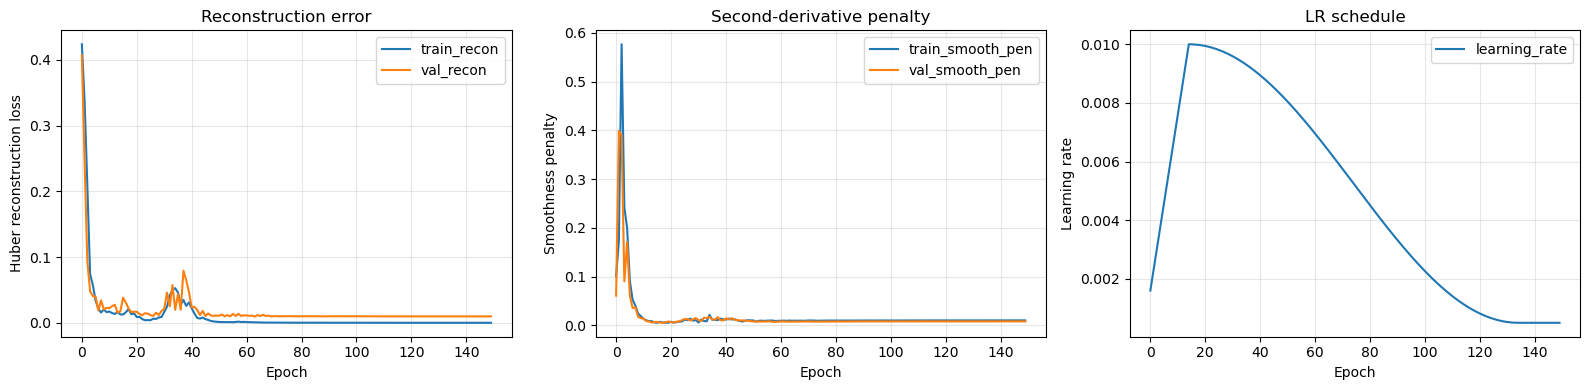

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_recon"], label="train_recon")
axes[0].plot(history["val_recon"], label="val_recon")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber reconstruction loss")
axes[0].set_title("Overall dual-head reconstruction")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_recon_cont"], label="train_recon_cont")
axes[1].plot(history["val_recon_cont"], label="val_recon_cont")
axes[1].plot(history["train_recon_norm"], label="train_recon_norm")
axes[1].plot(history["val_recon_norm"], label="val_recon_norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Per-head Huber loss")
axes[1].set_title("Continuum vs normalized-spectrum")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history["lr"], label="learning_rate")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_title("LR schedule")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()



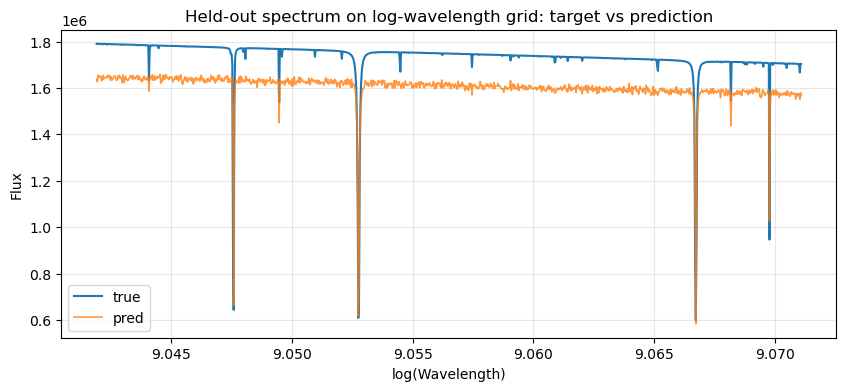

Test MSE (normalized targets): 0.013741803355515003
Test MSE (flux units): 5688441344.0
Input vector includes 11 features (params + mu).
Output points on selected grid: 1024


In [ ]:
test_batch = next(iter(loaders["test"]))
x_test, y_test = batch_to_xy(test_batch)
y_pred = np.asarray(state.apply_fn({"params": state.params}, jnp.asarray(x_test, dtype=jnp.float32)))

y_test_dual = denormalize_targets(y_test)
y_pred_dual = denormalize_targets(y_pred)

y_test_cont, y_test_norm = split_dual_targets(y_test_dual)
y_pred_cont, y_pred_norm = split_dual_targets(y_pred_dual)

i = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(target_axis, y_test_cont[i], label="true continuum", lw=1.5)
axes[0].plot(target_axis, y_pred_cont[i], label="pred continuum", lw=1.2, alpha=0.8)
axes[0].set_xlabel(target_axis_label)
axes[0].set_ylabel("Continuum")
axes[0].set_title(f"Held-out continuum on {target_domain} grid")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(target_axis, y_test_norm[i], label="true normalized", lw=1.5)
axes[1].plot(target_axis, y_pred_norm[i], label="pred normalized", lw=1.2, alpha=0.8)
axes[1].set_xlabel(target_axis_label)
axes[1].set_ylabel("Normalized flux")
axes[1].set_title(f"Held-out normalized spectrum on {target_domain} grid")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_mse_model_space = float(np.mean((y_pred - y_test) ** 2))
test_mse_continuum = float(np.mean((y_pred_cont - y_test_cont) ** 2))
test_mse_normalized = float(np.mean((y_pred_norm - y_test_norm) ** 2))
print("Test MSE (model-space targets):", test_mse_model_space)
print("Test MSE (continuum head):", test_mse_continuum)
print("Test MSE (normalized-spectrum head):", test_mse_normalized)
print("Input vector includes", x_test.shape[1], "features (params + mu).")
print("Output points per head on selected grid:", y_test_cont.shape[1])



## Notes

- Use `use_log_wavelength` in the preprocessing cell to switch between log-wavelength and linear-wavelength targets.
- Targets are built by interpolation onto `target_axis` (size `target_points`) before training.
- `normalize_interpolated_targets=True` normalizes interpolated train targets to zero mean / unit variance per output pixel.
- The optimizer uses a warmup + cosine decay learning-rate schedule controlled by `warmup_fraction` and `min_lr_ratio`.
- The reconstruction term uses Huber loss (`huber_delta`) for robustness to outlier pixels.
- A second-derivative regularizer (`lambda_smooth`) is added to reduce high-frequency noise in predictions.
- The reconstruction plot and `Test MSE (flux units)` are computed after denormalization back to physical flux.
- Optional range penalties (`lambda_hi`, `lambda_lo`) are available but disabled by default here.
- For higher-fidelity training, increase `target_points` and/or model capacity.
- If valid `mu` values are missing in your store, the notebook falls back to a zero-valued `mu` feature and prints a warning.
- Use `requirements-flax-ml.txt` to reproduce the tested FLAX/JAX environment.
- If your dataset stores `mu` under a different key, update `mu_key` detection in the data-inspection cell.

